<a href="https://colab.research.google.com/github/honeylouluzon/Guided-Project-Profitable-App-Profiles-for-the-App-Store-and-Google-Play-Markets/blob/main/Guided_Project_Profitable_App_Profiles_for_the_App_Store_and_Google_Play_Markets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Guided Project: Profitable App Profiles for the App Store and Google Play Markets

##About the Project
---

## Goal of the Project  

To understand what type of apps are likely to attract more users on Google Play and the App Store.


In [ ]:
import pandas as pd
from csv import reader
import re

##Dataset

In [ ]:
#Option 1: AppleStore.csv
connFile=open("/content/drive/MyDrive/Colab Notebooks/AppleStore.csv")
titleCol=1
priceCol=4
idCol=0
genreCol=11

In [ ]:
#Option 2: googleplaystore.csv
connFile=open("/content/drive/MyDrive/Colab Notebooks/googleplaystore.csv")
titleCol=0
priceCol=7
idCol=3 #reviewCol
genreCol=9

In [ ]:
#Set Dataset
readFile=reader(connFile)
data = list(readFile)
header = data[0]
dataset = data[1:]

##Explore

In [ ]:
def explore_data(dataset, start, end, rows_and_columns=False):
    dataset_slice = dataset[start:end]
    for row in dataset_slice:
        print(row)
        print('\n') # adds a new (empty) line after each row

    if rows_and_columns:
        print('Number of rows:', len(dataset))
        print('Number of columns:', len(dataset[0]))

The **explore_data()** function does the following:

Takes in four parameters:
- **dataset**, which will be a list of lists. The function assumes the argument for the dataset parameter doesn't have a header row
- **start** and **end**, which will both be integers and represent the starting and the ending indices of a slice from the dataset
- **rows_and_columns**, which will be a Boolean and has *False* as a default argument


In [ ]:
#Generate Dataset Content
page=1 #10 rows each
start= 0 + ((page-1)*10)
end= start + 10
explore_data(data,start,end,rows_and_columns=True)




['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', 'January 7, 2018', '1.0.0', '4.0.3 and up']


['Coloring book moana', 'ART_AND_DESIGN', '3.9', '967', '14M', '500,000+', 'Free', '0', 'Everyone', 'Art & Design;Pretend Play', 'January 15, 2018', '2.0.0', '4.0.3 and up']


['U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'ART_AND_DESIGN', '4.7', '87510', '8.7M', '5,000,000+', 'Free', '0', 'Everyone', 'Art & Design', 'August 1, 2018', '1.2.4', '4.0.3 and up']


['Sketch - Draw & Paint', 'ART_AND_DESIGN', '4.5', '215644', '25M', '50,000,000+', 'Free', '0', 'Teen', 'Art & Design', 'June 8, 2018', 'Varies with device', '4.2 and up']


['Pixel Draw - Number Art Coloring Book', 'ART_AND_DESIGN', '4.3', '967', '2.8M', '100,000+', 'Free', '0', 'Eve

##Data Cleaning

###Non-English apps and apps that aren't free

In [ ]:
# Check Non English and Not Free Apps Row
forDelete=[]
def checkNonEngRow():
  forDel=[]
  for row, record in enumerate(dataset):
    words = ""
    words = re.findall(r"[^\x00-\x7F]+",record[titleCol])
    cost = record[priceCol]
    if len(words)>3 or (cost!='0.0' and cost!='0' and cost!=0 and cost.lower()!='free'):
      print(record[priceCol],record[titleCol])
      forDelete.append(row)
  return f"For Deletion: {forDelete}"

print(checkNonEngRow())


$4.99 TurboScan: scan documents and receipts in PDF
$4.99 Tiny Scanner Pro: PDF Doc Scan
$4.99 TurboScan: scan documents and receipts in PDF
$4.99 Tiny Scanner Pro: PDF Doc Scan
$3.99 Puffin Browser Pro
$3.99 Moco+ - Chat, Meet People
$6.99 Calculator
$1.49 Truth or Dare Pro
$2.99 Private Dating, Hide App- Blue for PrivacyHider
$3.99 Ad Blocker for SayHi
$7.99 AMBW Dating App: Asian Men Black Women Interracial
$3.99 Moco+ - Chat, Meet People
$3.99 Sago Mini Hat Maker
$5.99 Fuzzy Numbers: Pre-K Number Foundation
$3.99 Toca Life: City
$3.99 Toca Life: Hospital
$4.99 My Talking Pet
$2.99 Meme Generator
$3.49 My CookBook Pro (Ad Free)
$4.99 Paprika Recipe Manager
$2.99 Pocket Yoga
$3.99 Meditation Studio
$2.99 Relax Melodies P: Sleep Sounds
$2.99 Pocket Yoga
$2.99 The Game of Life
$1.99 Clue
$4.99 The Room: Old Sins
$4.99 The Escapists
$4.99 Farming Simulator 18
$5.99 RollerCoaster Tycoon® Classic
$6.99 Call of Duty:Black Ops Zombies
$9.99 Star Wars ™: DIRTY
$4.99 Monument Valley 2
$3.99 T

In [ ]:
#Remove For Deletion Row
for i in range(len(forDelete)):
  maxNum=max(forDelete)
  print(f"Deleted: {maxNum}")
  forDelete.remove(maxNum)
  del dataset[maxNum]
print("Updating Record.....")
print(checkNonEngRow())

Deleted: 10798
Deleted: 10785
Deleted: 10782
Deleted: 10760
Deleted: 10735
Deleted: 10697
Deleted: 10690
Deleted: 10682
Deleted: 10679
Deleted: 10675
Deleted: 10674
Deleted: 10669
Deleted: 10668
Deleted: 10664
Deleted: 10662
Deleted: 10661
Deleted: 10651
Deleted: 10650
Deleted: 10645
Deleted: 10594
Deleted: 10586
Deleted: 10583
Deleted: 10570
Deleted: 10540
Deleted: 10531
Deleted: 10517
Deleted: 10472
Deleted: 10460
Deleted: 10459
Deleted: 10457
Deleted: 10453
Deleted: 10450
Deleted: 10448
Deleted: 10446
Deleted: 10442
Deleted: 10270
Deleted: 10122
Deleted: 10073
Deleted: 10072
Deleted: 10066
Deleted: 10060
Deleted: 10053
Deleted: 10052
Deleted: 10051
Deleted: 10050
Deleted: 10047
Deleted: 10046
Deleted: 10043
Deleted: 10041
Deleted: 10039
Deleted: 10037
Deleted: 10036
Deleted: 10035
Deleted: 10006
Deleted: 10005
Deleted: 9971
Deleted: 9941
Deleted: 9934
Deleted: 9932
Deleted: 9920
Deleted: 9917
Deleted: 9910
Deleted: 9905
Deleted: 9876
Deleted: 9869
Deleted: 9848
Deleted: 9828
Deleted

###Duplicate Items

In [ ]:
#Identify duplicate apps
def checkAppDuplicate():
  uniqueApp=[]
  duplicateApp=[]
  for row in dataset:
    name=row[titleCol].lower()
    if name in uniqueApp:
      duplicateApp.append(name.lower())
    else:
      uniqueApp.append(name.lower())
  return list(duplicateApp)

print(checkAppDuplicate())


['quick pdf scanner + ocr free', 'box', 'google my business', 'zoom cloud meetings', 'join.me - simple meetings', 'box', 'zenefits', 'google ads', 'google my business', 'slack', 'freshbooks classic', 'insightly crm', 'quickbooks accounting: invoicing & expenses', 'hipchat - chat built for teams', 'xero accounting software', 'mailchimp - email, marketing automation', 'crew - free messaging and scheduling', 'asana: organize team projects', 'google analytics', 'adwords express', 'accounting app - zoho books', 'invoice & time tracking - zoho', 'join.me - simple meetings', 'invoice 2go — professional invoices and estimates', 'signeasy | sign and fill pdf and other documents', 'quick pdf scanner + ocr free', 'genius scan - pdf scanner', 'tiny scanner - pdf scanner app', 'fast scanner : free pdf scan', 'mobile doc scanner (mdscan) lite', 'docs to go™ free office suite', 'officesuite : free office + pdf editor', 'slack', 'quickbooks accounting: invoicing & expenses', 'whatsapp messenger', 'mes

In [ ]:
#Full Record of duplicate apps
ListDuplicate=checkAppDuplicate()
print(header)
fullList=[]
for row in dataset:
  name=row[titleCol].lower()
  if name in ListDuplicate:
    fullList.append(row)
fullList=sorted(fullList)
tempCount=1
for row in fullList:
  print(f"{tempCount} : {row}")
  tempCount+=1


['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
1 : ['10 Best Foods for You', 'HEALTH_AND_FITNESS', '4.0', '2490', '3.8M', '500,000+', 'Free', '0', 'Everyone 10+', 'Health & Fitness', 'February 17, 2017', '1.9', '2.3.3 and up']
2 : ['10 Best Foods for You', 'HEALTH_AND_FITNESS', '4.0', '2490', '3.8M', '500,000+', 'Free', '0', 'Everyone 10+', 'Health & Fitness', 'February 17, 2017', '1.9', '2.3.3 and up']
3 : ['1800 Contacts - Lens Store', 'MEDICAL', '4.7', '23160', '26M', '1,000,000+', 'Free', '0', 'Everyone', 'Medical', 'July 27, 2018', '7.4.1', '5.0 and up']
4 : ['1800 Contacts - Lens Store', 'MEDICAL', '4.7', '23160', '26M', '1,000,000+', 'Free', '0', 'Everyone', 'Medical', 'July 27, 2018', '7.4.1', '5.0 and up']
5 : ['21-Day Meditation Experience', 'HEALTH_AND_FITNESS', '4.4', '11506', '15M', '100,000+', 'Free', '0', 'Everyone', 'Health & Fitness', 'August 2, 2018', '3.0.0', '4.1

In [ ]:

#Remove For Deletion Row

##Input for AppleStore
idx="1173990889"

##Input for GoogleStore
review='181823'
title='ASOS'

tempCount=1

ListDuplicate=checkAppDuplicate()
for i,row in enumerate(dataset):
  if idCol==3:
    #if row[idCol]==review and title.lower()==row[titleCol].lower():
      if row[titleCol].lower() in ListDuplicate:
        print(f"{tempCount} : Deleted: {row}")
        del dataset[i]
        ListDuplicate=checkAppDuplicate()
        tempCount+=1
  else:
    if row[idCol]==idx:
      if row[titleCol].lower() in ListDuplicate:
        print(f"{tempCount} : Deleted: {row}")
        del dataset[i]
        tempCount+=1
print("Updating Record...")
print(checkNonEngRow())

1 : Deleted: ['Coloring book moana', 'ART_AND_DESIGN', '3.9', '967', '14M', '500,000+', 'Free', '0', 'Everyone', 'Art & Design;Pretend Play', 'January 15, 2018', '2.0.0', '4.0.3 and up']
2 : Deleted: ['Mcqueen Coloring pages', 'ART_AND_DESIGN', 'NaN', '61', '7.0M', '100,000+', 'Free', '0', 'Everyone', 'Art & Design;Action & Adventure', 'March 7, 2018', '1.0.0', '4.1 and up']
3 : Deleted: ['UNICORN - Color By Number & Pixel Art Coloring', 'ART_AND_DESIGN', '4.7', '8145', '24M', '500,000+', 'Free', '0', 'Everyone', 'Art & Design;Creativity', 'August 2, 2018', '1.0.9', '4.4 and up']
4 : Deleted: ['Textgram - write on photos', 'ART_AND_DESIGN', '4.4', '295221', 'Varies with device', '10,000,000+', 'Free', '0', 'Everyone', 'Art & Design', 'July 30, 2018', 'Varies with device', 'Varies with device']
5 : Deleted: ['Wattpad 📖 Free Books', 'BOOKS_AND_REFERENCE', '4.6', '2914724', 'Varies with device', '100,000,000+', 'Free', '0', 'Teen', 'Books & Reference', 'August 1, 2018', 'Varies with devic

In [ ]:
#Apps Counts per Genre
def genreCounts():
  genreCount={}
  total=0
  for row in dataset:
    genre=row[genreCol].lower()
    if genre in genreCount:
      genreCount[genre]+=1
    else:
      genreCount[genre]=1
    total+=1
  for row in genreCount:
    genreCount[row]=genreCount[row]/total
  return genreCount,total

gCounts, gTotal=genreCounts()
print(f"TOTAL={gTotal}\n")
for row in sorted(gCounts):
  print(f"{row}={round(gCounts[row]*100,2)}%")




TOTAL=9010

action=3.14%
action;action & adventure=0.11%
adventure=0.68%
adventure;action & adventure=0.04%
adventure;education=0.01%
arcade=1.88%
arcade;action & adventure=0.12%
arcade;pretend play=0.01%
art & design=0.6%
art & design;action & adventure=0.01%
art & design;creativity=0.07%
art & design;pretend play=0.01%
auto & vehicles=0.91%
beauty=0.59%
board=0.37%
board;action & adventure=0.02%
board;brain games=0.08%
books & reference=2.14%
books & reference;education=0.01%
business=4.53%
card=0.46%
card;action & adventure=0.01%
casino=0.42%
casual=1.83%
casual;action & adventure=0.14%
casual;brain games=0.13%
casual;creativity=0.07%
casual;education=0.02%
casual;music & video=0.01%
casual;pretend play=0.23%
comics=0.61%
comics;creativity=0.01%
communication=3.27%
communication;creativity=0.01%
dating=1.89%
education=5.37%
education;action & adventure=0.03%
education;brain games=0.03%
education;creativity=0.04%
education;education=0.37%
education;music & video=0.03%
education;prete

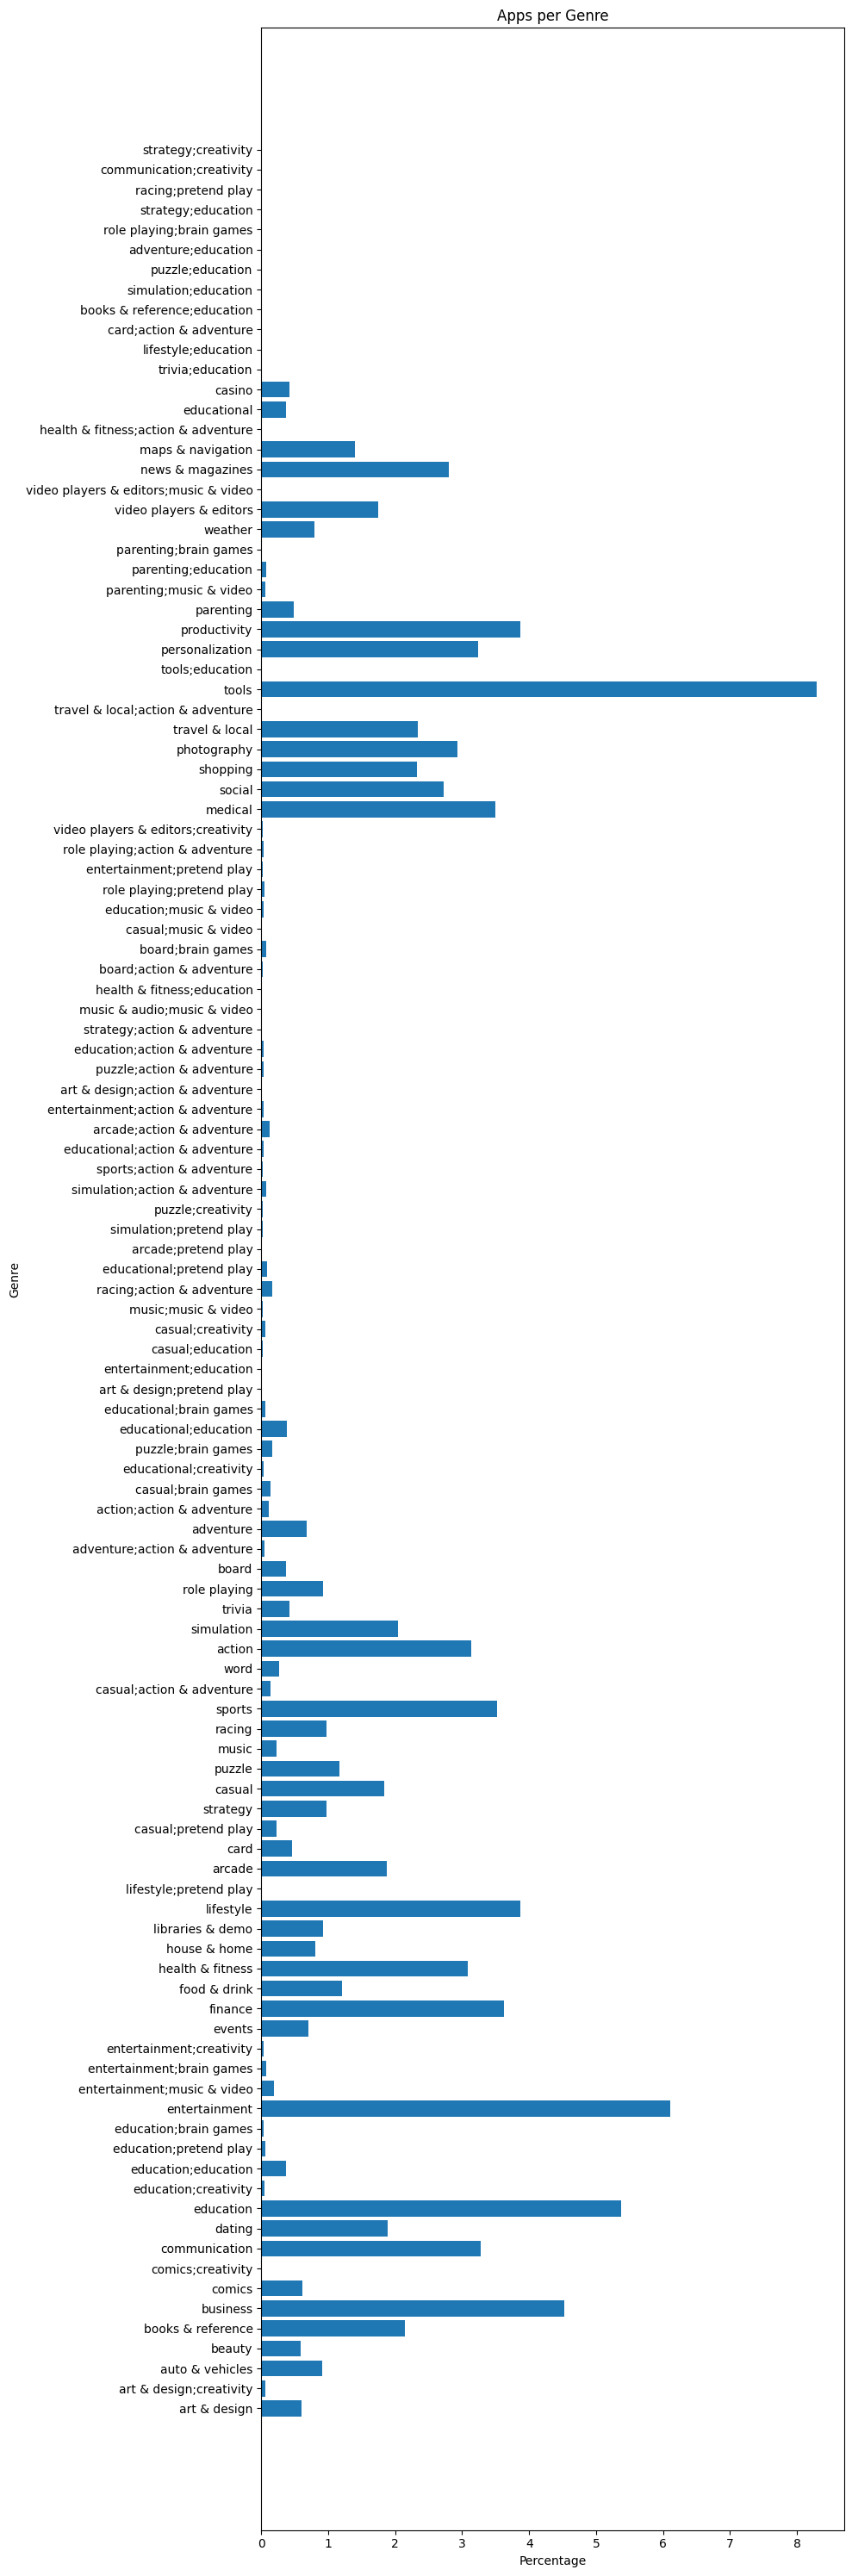

In [ ]:
#@title Apps per Genre Visuslization {display-mode:"form"}
#Genre Visualization

import matplotlib.pyplot as plt

gCounts,gTotal=genreCounts()
plt.figure(figsize=(10,30))
plt.barh(gCounts.keys(), [value * 100 for value in gCounts.values()])
plt.xlabel("Percentage")
plt.ylabel("Genre")
plt.title("Apps per Genre")
plt.tight_layout()
plt.show()

In [ ]:
def genreAveRatings():
  genre_total_ratings = {}
  genre_app_counts = {}

  for r in dataset:
    genre = r[genreCol].lower()
    rating_str = r[2] # Rating is at index 2

    # Skip records if rating is 'NaN' or cannot be converted to float
    if rating_str == 'NaN': # Explicitly check for string 'NaN'
      continue
    try:
      rating = float(rating_str)
    except ValueError:
      continue # Skip if string is not a valid float

    if genre in genre_total_ratings:
      genre_total_ratings[genre] += rating
      genre_app_counts[genre] += 1
    else:
      genre_total_ratings[genre] = rating
      genre_app_counts[genre] = 1

  genre_averages = {}
  for genre, total_rating in genre_total_ratings.items():
    if genre_app_counts[genre] > 0:
      genre_averages[genre] = round(total_rating / genre_app_counts[genre], 4)
    else:
      genre_averages[genre] = 0

  return genre_averages

print(genreAveRatings())

{'art & design': 4.3365, 'art & design;creativity': 4.35, 'auto & vehicles': 4.1847, 'beauty': 4.2786, 'books & reference': 4.3484, 'business': 4.0984, 'comics': 4.1698, 'comics;creativity': 4.8, 'communication': 4.1307, 'dating': 3.9676, 'education': 4.2995, 'education;creativity': 4.375, 'education;education': 4.3212, 'education;pretend play': 4.15, 'education;brain games': 4.4333, 'entertainment': 4.079, 'entertainment;music & video': 4.2, 'entertainment;brain games': 4.3, 'entertainment;creativity': 4.5333, 'events': 4.4356, 'finance': 4.1281, 'food & drink': 4.1604, 'health & fitness': 4.2389, 'house & home': 4.141, 'libraries & demo': 4.1781, 'lifestyle': 4.083, 'lifestyle;pretend play': 4.0, 'arcade': 4.2805, 'card': 4.0487, 'casual;pretend play': 4.1143, 'strategy': 4.2012, 'casual': 4.1069, 'puzzle': 4.3602, 'music': 4.19, 'racing': 4.1476, 'sports': 4.2331, 'casual;action & adventure': 4.2, 'word': 4.3391, 'action': 4.2406, 'simulation': 4.1399, 'trivia': 4.0393, 'role playin

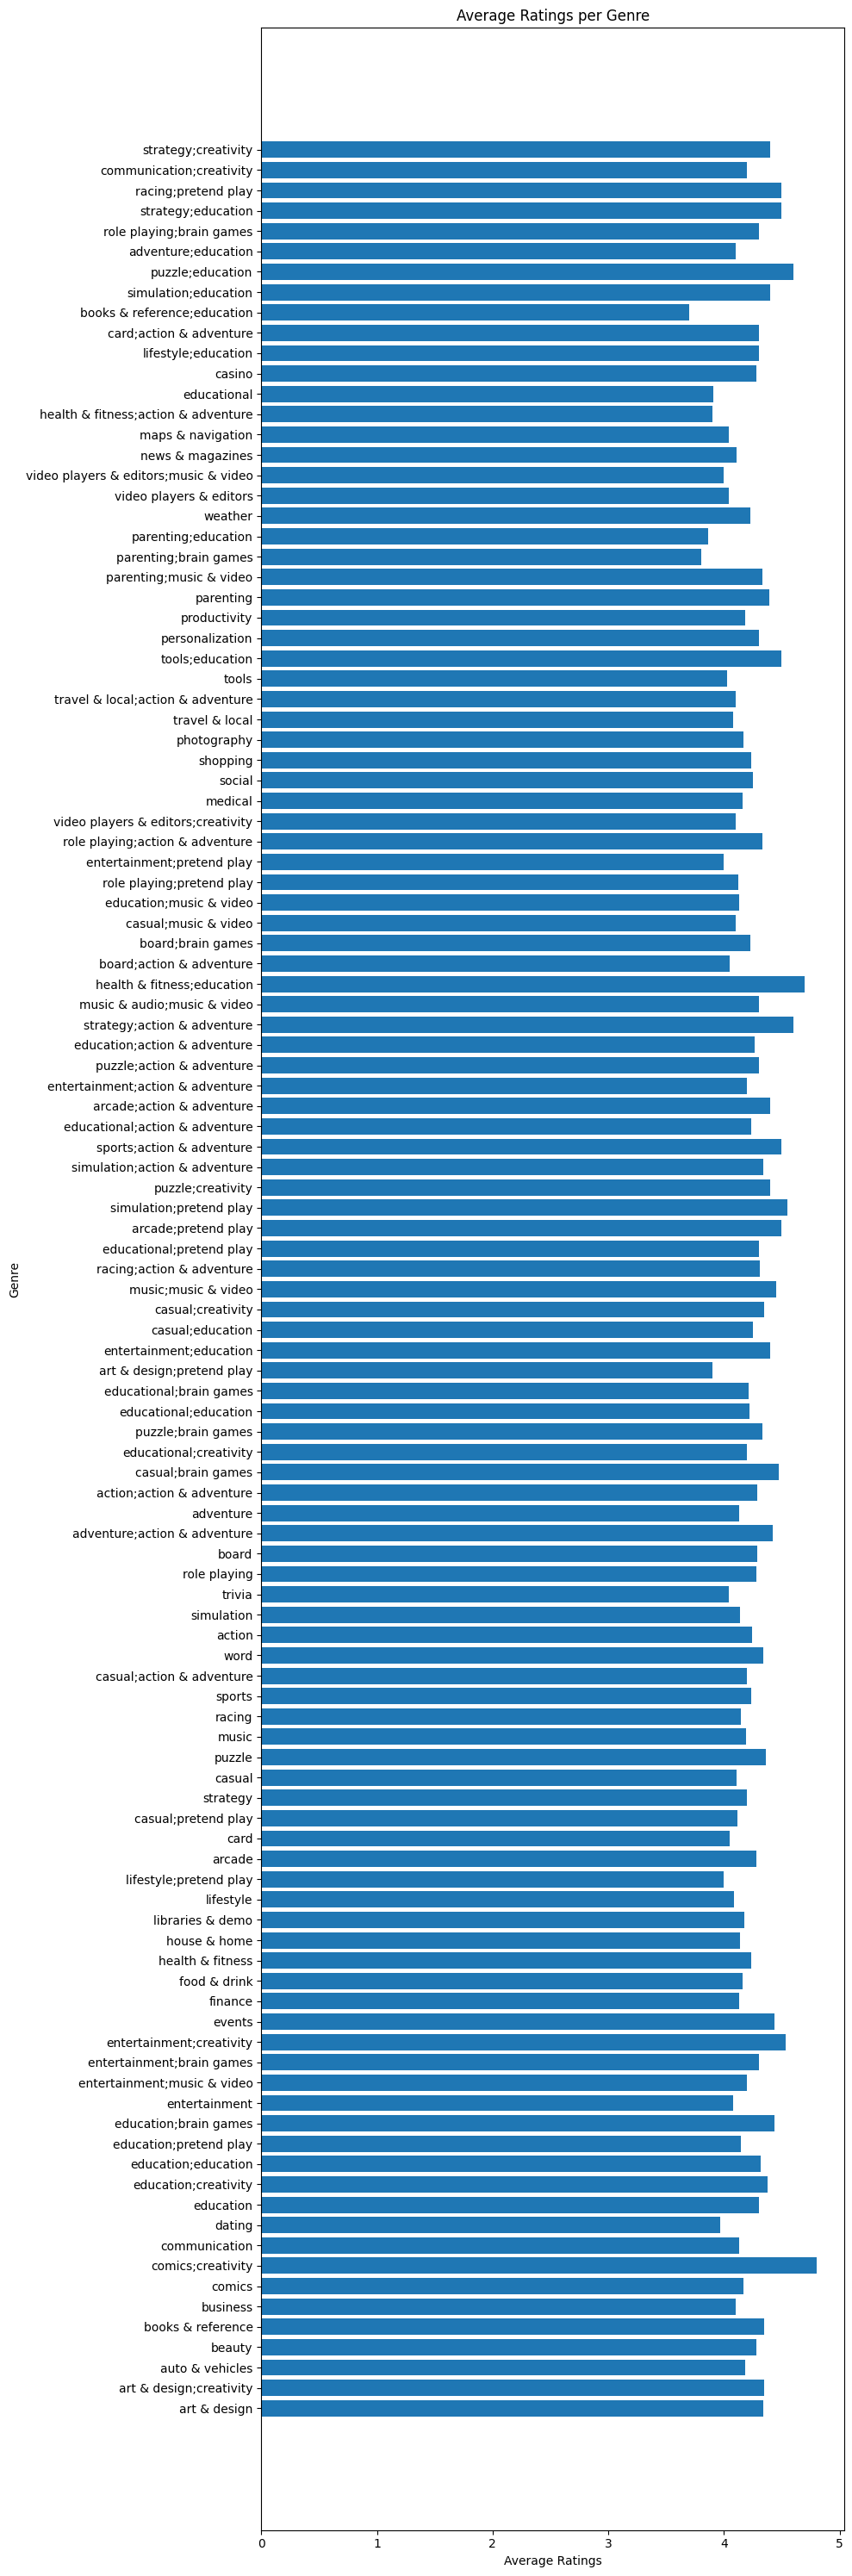

In [ ]:
#@title Average Ratings per Genre Visuslization {display-mode:"form"}
#Genre Ratings Visualization

import matplotlib.pyplot as plt

gAve=genreAveRatings()
plt.figure(figsize=(10,30))
plt.barh(gAve.keys(), gAve.values())
plt.xlabel("Average Ratings")
plt.ylabel("Genre")
plt.title("Average Ratings per Genre")
plt.tight_layout()
plt.show()